## Load and Vectorize Text Data

In [14]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the 'ALLDATA' sheet from the Excel file
df = pd.read_excel('youtube_comments_cleaned.xlsx', sheet_name='ALLDATA')

# Extract the 'cleaned_text' column, handle missing values by filling with an empty string, and convert to string type
cleaned_text = df['cleaned_text'].fillna('').astype(str)

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Apply TF-IDF vectorizer to the 'cleaned_text' column
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_text)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("First 5 rows of TF-IDF matrix (sparse format):")
print(tfidf_matrix[:5])

TF-IDF matrix shape: (1086, 2457)
First 5 rows of TF-IDF matrix (sparse format):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23 stored elements and shape (5, 2457)>
  Coords	Values
  (0, 99)	0.46888685252379303
  (0, 51)	0.6955152562238944
  (0, 1628)	0.5444296537571601
  (1, 1628)	0.34529252598305665
  (1, 2001)	0.5044506159139335
  (1, 323)	0.476424267469108
  (1, 1374)	0.31499969644897285
  (1, 2172)	0.30276998400690197
  (1, 772)	0.45653925679215407
  (2, 1966)	0.5364014109315218
  (2, 1282)	0.2589751930334989
  (2, 2289)	0.49664732790275373
  (2, 2320)	0.33289688160399156
  (2, 791)	0.5364014109315218
  (3, 2030)	0.3337734108577629
  (3, 1987)	0.5491393747262752
  (3, 2184)	0.48019318790595017
  (3, 585)	0.5186302010324958
  (3, 2212)	0.2957676016661125
  (4, 2186)	0.5035402420877553
  (4, 788)	0.6078890815628774
  (4, 2026)	0.21750642038976953
  (4, 888)	0.5741158822085269


## Determine Optimal K (Elbow Method)




In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Define a range of k values to test
k_range = range(1, 11)  # Testing k from 1 to 10

# Initialize an empty list to store inertia values
inertia_values = []

# Loop through each k in the defined range
for k in k_range:
    # Instantiate KMeans model with current k and random_state for reproducibility
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit the KMeans model to the tfidf_matrix
    kmeans.fit(tfidf_matrix)

    # Append the inertia_ attribute to the inertia_values list
    inertia_values.append(kmeans.inertia_)

print("Inertia values calculated for k from 1 to 10.")
print(f"K values tested: {list(k_range)}")
print(f"Corresponding Inertia values: {inertia_values}")

Inertia values calculated for k from 1 to 10.
K values tested: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Corresponding Inertia values: [1015.5981094986859, 1012.1448125320331, 996.5758323791478, 983.8685586267763, 968.7569074394132, 961.576914828059, 955.7444140577995, 956.0463077014587, 950.4340314914782, 947.690206758021]


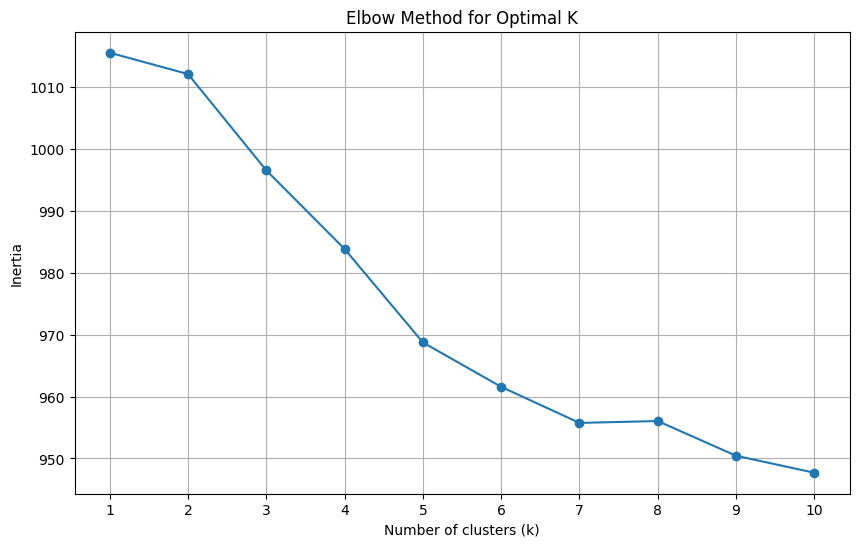

In [16]:
import matplotlib.pyplot as plt

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

## Determine Optimal K (Silhouette Method)



In [17]:
from sklearn.metrics import silhouette_score

# Initialize an empty list to store Silhouette scores
silhouette_scores = []

# Loop through each k in the defined range, starting from 2
# Silhouette score is not defined for k=1
for k in k_range[1:]:
    # Instantiate KMeans model with current k and random_state for reproducibility
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit the KMeans model to the tfidf_matrix and predict cluster labels
    cluster_labels = kmeans.fit_predict(tfidf_matrix)

    # Calculate the Silhouette score and append it to the list
    silhouette_scores.append(silhouette_score(tfidf_matrix, cluster_labels))

print("Silhouette scores calculated for k from 2 to 10.")
print(f"K values tested: {list(k_range[1:])}")
print(f"Corresponding Silhouette scores: {silhouette_scores}")

Silhouette scores calculated for k from 2 to 10.
K values tested: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Corresponding Silhouette scores: [np.float64(0.019155599253683934), np.float64(0.025986233082331292), np.float64(0.028692880606742282), np.float64(0.03574861944632644), np.float64(0.038023299991747354), np.float64(0.04058055985257057), np.float64(0.04053247735273965), np.float64(0.04227410690908752), np.float64(0.0429238179580235)]


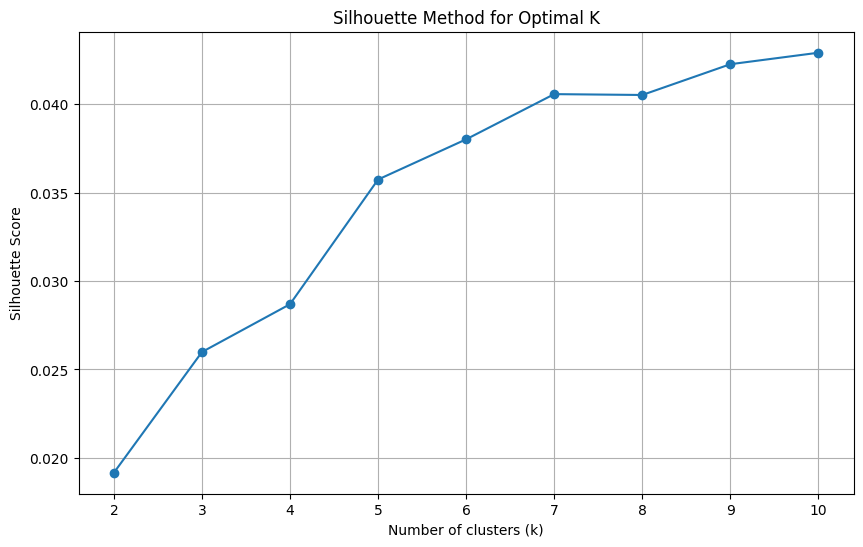

In [18]:
import matplotlib.pyplot as plt

# Plot the Silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range[1:], silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal K')
plt.xticks(list(k_range[1:]))
plt.grid(True)
plt.show()

In [19]:
# optimal_k_silhouette_index = np.argmax(silhouette_scores)
# optimal_k_silhouette = k_range[1:][optimal_k_silhouette_index]
# max_silhouette_score = silhouette_scores[optimal_k_silhouette_index]

# print(f"The optimal number of clusters (k) according to the Silhouette method is: {optimal_k_silhouette}")
# print(f"The maximum Silhouette score achieved was: {max_silhouette_score:.4f}")

## Perform K-Means Clustering



In [20]:
optimal_k = 5 # Chosen based on the Silhouette method and considering the Elbow method

# Instantiate KMeans model with the optimal k and random_state for reproducibility
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# Fit the KMeans model to the tfidf_matrix and predict cluster labels
df['cluster_label'] = kmeans_optimal.fit_predict(tfidf_matrix)

print(f"K-Means clustering performed with k = {optimal_k}.")
print("First 5 rows of DataFrame with new 'cluster_label' column:")
print(df[['cleaned_text', 'cluster_label']].head())

K-Means clustering performed with k = 5.
First 5 rows of DataFrame with new 'cluster_label' column:
                                        cleaned_text  cluster_label
0                 everything alex absolutely perfect              4
1  everything skinny british man perfect thank ev...              4
2  shoulder it's like understands everything i've...              4
3   songs simultaneously therapeutic depressing time              4
4                  therapy expensivebrthis song free              4


## Perform Topic Modeling




In [21]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(n_components=optimal_k, random_state=42, learning_method='batch')

# Fit the LDA model to the tfidf_matrix
lda_model.fit(tfidf_matrix)

print(f"LDA model fitted with {optimal_k} topics.")

LDA model fitted with 5 topics.


## Display Top Words per Topic/Cluster


In [22]:
feature_names = tfidf_vectorizer.get_feature_names_out()
n_top_words = 10

print(f"Displaying top {n_top_words} words per topic:")
for topic_idx, topic in enumerate(lda_model.components_):
    top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    print(f"Topic {topic_idx + 1}: {', '.join(top_features)}")

Displaying top 10 words per topic:
Topic 1: hits, anymore, rex, song, really, im, songs, omg, different, miss
Topic 2: song, beautiful, masterpiece, perfect, damn, like, feel, wow, love, underrated
Topic 3: anymore, song, thank, amazing, wish, voice, man, samebrit, love, best
Topic 4: crying, song, ily, relate, im, like, fav, know, lov, listen
Topic 5: love, song, good, yes, alex, album, rex, version, fucking, like


### Contoh Komentar per Klaster K-Means

In [23]:
for i in range(optimal_k):
    print(f"\n--- Klaster K-Means {i} ---")
    # Ambil 5 contoh komentar dari setiap klaster
    sample_comments = df[df['cluster_label'] == i]['cleaned_text'].sample(min(5, len(df[df['cluster_label'] == i]))).tolist()
    for j, comment in enumerate(sample_comments):
        print(f"{j+1}. {comment}")


--- Klaster K-Means 0 ---
1. love alex
2. love youuuu
3. love song
4. love much
5. love uuuu

--- Klaster K-Means 1 ---
1. i've listening music almost 3 years first time i've ever seen art artistic people enjoy stuff without feeling need see enjoy
2. pls release new album
3. need version spotify pls
4. dont need therapy rex orange county
5. quoti wish didnt need get help doquot line literally relate

--- Klaster K-Means 2 ---
1. i'll keep pictures saved safe placebrwow look weird herebrmy face changed nowbrit's big shamebrso many feelings struggling leave mouthbrand it's rare let downbrin big waybrbut enough time found enough reason accept thatbrit's anymorebri lost joy facebrmy life simple beforebri happy coursebrbut things got much harderbrnow it's hard ignorebrit's anymorebrit's anymorebrit's it's shame 'causebri spend long time putting peoplebrputting best facebrit's normal stop things wrong waybrit's four o'clock still it's long daybri wanna hit haybrpeople knocking like every da

### Contoh Komentar Representatif per Topik LDA

In [24]:
import numpy as np

# Transform TF-IDF matrix to topic distribution for each document
doc_topic_dist = lda_model.transform(tfidf_matrix)

for i in range(optimal_k):
    print(f"\n--- Topik LDA {i+1}: {', '.join(top_features)} ---")
    # Dapatkan indeks dokumen yang paling mewakili topik ini
    # Ini dilakukan dengan menemukan dokumen yang memiliki probabilitas tertinggi untuk topik 'i'
    top_doc_indices = np.argsort(doc_topic_dist[:, i])[::-1][:5]

    # Tampilkan 5 contoh komentar dari dokumen-dokumen ini
    for j, doc_idx in enumerate(top_doc_indices):
        print(f"{j+1}. {df.loc[doc_idx, 'cleaned_text']}")



--- Topik LDA 1: love, song, good, yes, alex, album, rex, version, fucking, like ---
1. bueno ya basta alex cuando el nuevo lbum nada ms encampanaste con tu live en insta dicindo que ya tenas algunas canciones listas aunque sea un single flaco
2. una de las mejores canciones del 20202021brde las pocas que valen la pena escuchar con bondad realidad brsaludos desde mxicobrgracias rex orange country
3. doubt work orange county hope see soon lived utah echoed life pony vinyl think song rings loudest
4. aiiiii perfeitoooooo obrigado por fazer bem com essas msicas rex brasil te amaaa
5. i'm mini concert house alex's song anyone wanna come course gotta come else gonna sing songs

--- Topik LDA 2: love, song, good, yes, alex, album, rex, version, fucking, like ---
1. want share year ago songs untitled happiness songs could really relate felt like companions broke struggling find job back felt like disappointment everyone especially man said would proud shortlist accomplishments lack new news 